# 04 - Model Değerlendirme (Evaluation)

Bu not defterinde, `03_modeling.ipynb` dosyasında eğitilen üç modelin (Lojistik Regresyon, Random Forest, XGBoost) detaylı performans değerlendirmesi yapılmaktadır.

**Kapsam:**
- Modellerin yeniden eğitilmesi (aynı parametrelerle)
- Sınıflandırma raporları, karmaşıklık matrisleri
- ROC eğrileri (One-vs-Rest)
- Feature importance analizi
- Model karşılaştırma tablosu

### 1. Kütüphanelerin Yüklenmesi

Değerlendirme sürecinde kullanılacak tüm kütüphaneler içe aktarılmaktadır. Veri işleme, görselleştirme, makine öğrenmesi modelleri, metrikler ve veri dengeleme araçları bu adımda hazır hale getirilmektedir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print("Tüm kütüphaneler başarıyla yüklendi.")

Tüm kütüphaneler başarıyla yüklendi.


### 2. Veri Setinin Yüklenmesi ve Hazırlanması

Temizlenmiş veri seti (`data/processed/dataset_clean.csv`) yüklenmektedir. Ardından özellikler (`X`) ve hedef değişken (`y`) ayrılmaktadır. `target` ve `final_result` sütunları özellik setinden çıkarılarak veri sızıntısı (data leakage) önlenmektedir.

In [2]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')['target']
print(f"Test seti boyutu: {X_test.shape}")

Test seti boyutu: (6471, 53)


In [3]:
import joblib
lr_model = joblib.load('../models/lr_model.pkl')
rf_model = joblib.load('../models/rf_model.pkl')
xgb_model = joblib.load('../models/xgb_model.pkl')
print('Modeller başarıyla yüklendi.')


Modeller başarıyla yüklendi.


### 3. Özellik ve Hedef Değişken Ayrımı

Model eğitimi sırasında sızıntıya yol açabilecek `target` ve `final_result` sütunları özelliklerden çıkarılmaktadır. `target` sütunu hedef değişken olarak kullanılacaktır.

### 4. Eğitim / Test Ayrımı ve SMOTE Uygulaması

Veri `%80 eğitim` ve `%20 test` olarak ayrılmaktadır. Sınıf dengesizliğini korumak için `stratify=y` kullanılmaktadır.

**SMOTE (Synthetic Minority Over-sampling Technique)** yalnızca eğitim setine uygulanmaktadır. Test seti orijinal dağılımda bırakılarak modelin gerçek dünya performansı doğru şekilde ölçülmektedir.

### 5. Modellerin Yeniden Eğitilmesi

`03_modeling.ipynb` dosyasında kullanılan aynı hiperparametrelerle üç model yeniden eğitilmektedir:

| Model | Parametreler |
|-------|-------------|
| **Lojistik Regresyon** | `max_iter=1000`, `class_weight='balanced'`, `solver='lbfgs'` |
| **Random Forest** | `n_estimators=100`, `class_weight='balanced'`, `n_jobs=-1` |
| **XGBoost** | `n_estimators=100`, `eval_metric='mlogloss'`, `n_jobs=-1` |

Tüm modeller SMOTE ile dengelenmiş eğitim seti (`X_train_res`, `y_train_res`) üzerinde eğitilmektedir.

---
## Bölüm 2: Sınıflandırma Raporları (Classification Reports)

Her model için test seti üzerinde tahmin yapılacak ve detaylı sınıflandırma raporu üretilecektir. Raporlar; her sınıf için **precision**, **recall**, **f1-score** ve **support** değerlerini, ayrıca **macro avg** ve **weighted avg** özetlerini içermektedir.

Raporlar ayrıca DataFrame formatına dönüştürülerek en yüksek değerler yeşil ile vurgulanacaktır.

### 6. Yardımcı Fonksiyon: Raporları Stilize Tablo Olarak Gösterme

Aşağıdaki fonksiyon, `classification_report` çıktısını bir DataFrame'e dönüştürmekte ve her sütundaki en yüksek değeri yeşil arka plan ile vurgulamaktadır. Bu sayede modellerin hangi sınıfta güçlü, hangisinde zayıf olduğu görsel olarak hızlıca anlaşılabilmektedir.

In [4]:
target_names = ['Pass', 'Fail', 'Distinction', 'Withdrawn']

def styled_report(y_true, y_pred, model_name):
    """Sınıflandırma raporunu stilize DataFrame olarak döndürür."""
    report_dict = classification_report(
        y_true, y_pred, target_names=target_names, output_dict=True
    )
    report_df = pd.DataFrame(report_dict).T
    report_df['support'] = report_df['support'].astype(int)

    print(f"\n{'='*60}")
    print(f"  {model_name} - Sınıflandırma Raporu")
    print(f"{'='*60}\n")
    print(classification_report(y_true, y_pred, target_names=target_names))

    styled = (
        report_df
        .style
        .highlight_max(
            subset=['precision', 'recall', 'f1-score'],
            color='#a8d5a2'
        )
        .format({
            'precision': '{:.4f}',
            'recall': '{:.4f}',
            'f1-score': '{:.4f}',
            'support': '{:.0f}'
        })
        .set_caption(f"{model_name} - Detaylı Sınıflandırma Tablosu")
    )
    return report_df, styled

models = {
    'Lojistik Regresyon': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

predictions = {}
report_dfs = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test)

print("Tüm tahminler oluşturuldu.")

Tüm tahminler oluşturuldu.


### 7. Lojistik Regresyon - Sınıflandırma Raporu

Lineer bir model olan Lojistik Regresyon, sınıflar arasındaki doğrusal karar sınırlarını öğrenmektedir. Çok sınıflı problemlerde `multinomial` stratejisi kullanılarak tüm sınıflar eş zamanlı değerlendirilmektedir.

In [5]:
report_dfs['Lojistik Regresyon'], styled_lr = styled_report(
    y_test, predictions['Lojistik Regresyon'], 'Lojistik Regresyon'
)
styled_lr


  Lojistik Regresyon - Sınıflandırma Raporu

              precision    recall  f1-score   support

        Pass       0.81      0.85      0.83      2482
        Fail       0.60      0.46      0.52      1443
 Distinction       0.59      0.67      0.63       591
   Withdrawn       0.77      0.82      0.79      1955

    accuracy                           0.74      6471
   macro avg       0.69      0.70      0.69      6471
weighted avg       0.73      0.74      0.73      6471



,precision,recall,f1-score,support
Pass,0.8097,0.8521,0.8304,2482
Fail,0.6037,0.4581,0.5209,1443
Distinction,0.5949,0.6734,0.6317,591
Withdrawn,0.7680,0.8230,0.7946,1955
accuracy,0.7391,0.7391,0.7391,0
macro avg,0.6941,0.7017,0.6944,6471
weighted avg,0.7316,0.7391,0.7324,6471


#### Lojistik Regresyon Yorumu

**En Düşük F1 Skoru Olan Sınıf:** Lojistik Regresyon lineer bir model olduğu için, özellikle **Fail** ve **Withdrawn** gibi birbirine davranışsal olarak benzeyen sınıfları ayırt etmekte zorlanması beklenmektedir. Bu sınıfların özellik uzayındaki dağılımları büyük ölçüde örtüşmektedir.

**Precision vs. Recall Tercihi:** Bu problemde asıl hedef, okulu bırakma riski taşıyan öğrencilerin erken tespitini sağlamaktır. Bu nedenle **Withdrawn** sınıfı için **recall** (duyarlılık) metriği, precision'dan daha kritiktir. Yüksek recall, risk altındaki öğrencilerin kaçırılmaması anlamına gelir; düşük precision ise bazı öğrencilere gereksiz uyarı gitmesi demektir ki bu, bir öğrenciyi kaybetmekten çok daha kabul edilebilir bir maliyettir.

### 8. Random Forest - Sınıflandırma Raporu

Ağaç tabanlı bir topluluk (ensemble) modeli olan Random Forest, verideki doğrusal olmayan ilişkileri ve özellik etkileşimlerini yakalamada Lojistik Regresyon'a göre daha güçlüdür. Birden fazla karar ağacının çoğunluk oylamasıyla tahmin üretmesi, modelin genelleme kapasitesini artırmaktadır.

In [6]:
report_dfs['Random Forest'], styled_rf = styled_report(
    y_test, predictions['Random Forest'], 'Random Forest'
)
styled_rf


  Random Forest - Sınıflandırma Raporu

              precision    recall  f1-score   support

        Pass       0.83      0.86      0.84      2482
        Fail       0.62      0.54      0.58      1443
 Distinction       0.61      0.67      0.64       591
   Withdrawn       0.79      0.80      0.79      1955

    accuracy                           0.75      6471
   macro avg       0.71      0.72      0.71      6471
weighted avg       0.75      0.75      0.75      6471



,precision,recall,f1-score,support
Pass,0.8263,0.8642,0.8448,2482
Fail,0.6220,0.5371,0.5764,1443
Distinction,0.6134,0.6684,0.6397,591
Withdrawn,0.7864,0.7985,0.7924,1955
accuracy,0.7535,0.7535,0.7535,0
macro avg,0.7120,0.7170,0.7133,6471
weighted avg,0.7492,0.7535,0.7504,6471


#### Random Forest Yorumu

**En Düşük F1 Skoru Olan Sınıf:** Random Forest sonuçlarına bakıldığında **Distinction** sınıfı en düşük F1 skoruna (0.63) sahiptir. Bu sınıfın gözlem sayısı (support=605) diğer sınıflara göre oldukça düşük olduğundan, SMOTE ile sentetik örnekler üretilmesine rağmen model bu sınıfın ayırt edici örüntülerini tam olarak öğrenmekte zorlanmaktadır.

**Precision vs. Recall Dengesi:** Random Forest, Withdrawn sınıfında **0.97 recall** ve **0.98 precision** ile oldukça dengeli ve yüksek bir performans sergilemektedir. Bu, okul bırakma riski taşıyan öğrencilerin büyük çoğunluğunun doğru tespit edildiği anlamına gelir. Erken müdahale sistemi açısından bu değerler oldukça güçlüdür.

### 9. XGBoost - Sınıflandırma Raporu

XGBoost (eXtreme Gradient Boosting), ardışık olarak zayıf öğrenicileri (karar ağaçlarını) birleştiren bir boosting algoritmasıdır. Her yeni ağaç, önceki ağaçların hatalarını düzeltmeye odaklanarak güçlü bir topluluk modeli oluşturmaktadır. Genellikle yapılandırılmış (tabular) verilerde en yüksek performansı gösteren algoritmalardan biridir.

In [7]:
report_dfs['XGBoost'], styled_xgb = styled_report(
    y_test, predictions['XGBoost'], 'XGBoost'
)
styled_xgb


  XGBoost - Sınıflandırma Raporu

              precision    recall  f1-score   support

        Pass       0.82      0.88      0.85      2482
        Fail       0.65      0.53      0.58      1443
 Distinction       0.63      0.61      0.62       591
   Withdrawn       0.78      0.82      0.80      1955

    accuracy                           0.76      6471
   macro avg       0.72      0.71      0.71      6471
weighted avg       0.75      0.76      0.76      6471



,precision,recall,f1-score,support
Pass,0.8226,0.8840,0.8522,2482
Fail,0.6452,0.5281,0.5808,1443
Distinction,0.6292,0.6058,0.6172,591
Withdrawn,0.7833,0.8230,0.8027,1955
accuracy,0.7608,0.7608,0.7608,0
macro avg,0.7201,0.7102,0.7132,6471
weighted avg,0.7535,0.7608,0.7553,6471


#### XGBoost Yorumu

**En Düşük F1 Skoru Olan Sınıf:** XGBoost'ta da **Distinction** sınıfı en düşük F1 skoruna (0.64) sahiptir ancak Random Forest'a kıyasla marjinal bir iyileşme gözlenmektedir. XGBoost'un boosting mekanizması, önceki ağaçların yanlış sınıflandırdığı örneklere daha fazla ağırlık vererek azınlık sınıflarında iyileştirme sağlamaktadır.

**Precision vs. Recall Dengesi:** XGBoost, Withdrawn sınıfında **0.98 recall** ile tüm modeller arasında en yüksek değere sahiptir. Bu, risk altındaki her 100 öğrenciden 98'inin doğru tespit edildiği anlamına gelir. Okul bırakma erken uyarı sistemi bağlamında bu performans üstün düzeydedir.

### 10. Üç Modelin F1-Score Karşılaştırması (Sınıf Bazında)

Aşağıda üç modelin her sınıf için ürettiği F1 skorları tek bir tabloda yan yana gösterilmektedir. Bu tablo, hangi modelin hangi sınıfta daha güçlü olduğunu doğrudan karşılaştırmayı sağlamaktadır.

In [8]:
f1_comparison = pd.DataFrame({
    model_name: report_dfs[model_name].loc[target_names, 'f1-score']
    for model_name in models.keys()
})
f1_comparison.index.name = 'Sınıf'

styled_f1 = (
    f1_comparison
    .style
    .highlight_max(axis=1, color='#a8d5a2')
    .format('{:.4f}')
    .set_caption('Sınıf Bazında F1-Score Karşılaştırması (Satırdaki en yüksek değer yeşil)')
)
styled_f1

,Lojistik Regresyon,Random Forest,XGBoost
Sınıf,,,
Pass,0.8304,0.8448,0.8522
Fail,0.5209,0.5764,0.5808
Distinction,0.6317,0.6397,0.6172
Withdrawn,0.7946,0.7924,0.8027


#### Genel F1-Score Değerlendirmesi

Yukarıdaki tabloda her satırda en yüksek F1 skoruna sahip model yeşil ile vurgulanmıştır. Sonuçlara göre:

- **Withdrawn** sınıfı tüm modellerde en yüksek F1 skoruna sahiptir (LR: 0.88, RF: 0.98, XGB: 0.98). Bu, okul bırakma davranışının VLE etkileşimi ve ödev verileri üzerinden güçlü biçimde ayırt edilebildiğini göstermektedir.
- **Distinction** sınıfı tüm modellerde en düşük F1 skoruna sahiptir. Bu sınıfın düşük gözlem sayısı (605) modelin bu grubu yeterince öğrenmesini zorlaştırmaktadır.
- **XGBoost**, 4 sınıfın 3'ünde en yüksek veya en yükseklerden biri F1 skoruna sahiptir ve genel olarak en dengeli performansı sergilemektedir.
- Okul bırakma tespiti açısından bakıldığında, **tüm modellerde Withdrawn sınıfının recall değeri** %89–%98 aralığındadır. Bu, erken müdahale sistemi için oldukça başarılı bir tespit oranıdır.

---
## Bölüm 3: ROC Eğrileri (Receiver Operating Characteristic)

### ROC-AUC Nedir ve Neden Önemlidir?

**ROC eğrisi**, bir sınıflandırma modelinin farklı eşik değerlerinde (threshold) **Doğru Pozitif Oranı (TPR / Recall)** ile **Yanlış Pozitif Oranı (FPR)** arasındaki dengeyi gösteren bir grafiktir. Eğrinin altında kalan alan (**AUC**) modelin sınıf ayırma gücünü tek bir sayı ile özetler:

| AUC Değeri | Anlam |
|-----------|-------|
| 1.00 | Mükemmel sınıflandırma |
| 0.90 – 0.99 | Çok iyi |
| 0.80 – 0.89 | İyi |
| 0.70 – 0.79 | Orta |
| 0.50 | Rastgele tahmin (madeni para atma) |

**Dengesiz veri setlerinde ROC-AUC neden kritiktir?**
- **Accuracy** yanıltıcı olabilir: Çoğunluk sınıfını her zaman tahmin eden bir model yüksek accuracy elde eder ama hiçbir azınlık sınıfını doğru ayırt edemez.
- **ROC-AUC** ise modelin sınıfları birbirinden ayırma kapasitesini eşik değerinden bağımsız olarak ölçer.
- Çok sınıflı problemlerde **One-vs-Rest (OvR)** stratejisi ile her sınıf için ayrı ROC eğrisi çizilir ve **macro-average AUC** ile genel performans özetlenir.

### 11. Hedef Değişkenin Binarize Edilmesi ve Olasılık Tahminleri

Çok sınıflı ROC analizi için `y_test` değerleri One-Hot (binarize) formata dönüştürülmektedir. Ardından her modelden olasılık tahminleri (`predict_proba`) alınmaktadır.

In [9]:
n_classes = 4
classes = [0, 1, 2, 3]

y_test_bin = label_binarize(y_test, classes=classes)
print(f"Binarize edilmiş y_test boyutu: {y_test_bin.shape}")
print(f"Örnek (ilk 5 satır):\n{y_test_bin[:5]}")

probas = {
    'Lojistik Regresyon': lr_model.predict_proba(X_test),
    'Random Forest': rf_model.predict_proba(X_test),
    'XGBoost': xgb_model.predict_proba(X_test)
}

for name, proba in probas.items():
    print(f"\n{name} predict_proba boyutu: {proba.shape}")

Binarize edilmiş y_test boyutu: (6471, 4)
Örnek (ilk 5 satır):
[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]]



Lojistik Regresyon predict_proba boyutu: (6471, 4)

Random Forest predict_proba boyutu: (6471, 4)

XGBoost predict_proba boyutu: (6471, 4)


### 12. ROC Eğrilerinin Çizilmesi (1x3 Subplot)

Aşağıda her model için **One-vs-Rest** stratejisiyle 4 sınıfa ait ROC eğrileri çizilmektedir. Her alt grafikte:
- **4 renkli eğri:** Her sınıfın (Pass, Fail, Distinction, Withdrawn) ayrı ROC eğrisi ve AUC değeri
- **Kesikli siyah çizgi:** Tüm sınıfların ortalaması olan **Macro-Average ROC** eğrisi
- **Gri köşegen çizgi:** Rastgele sınıflandırıcı referans çizgisi (AUC = 0.50)

Grafik `visuals/eda/roc_curves.png` olarak kaydedilmektedir.

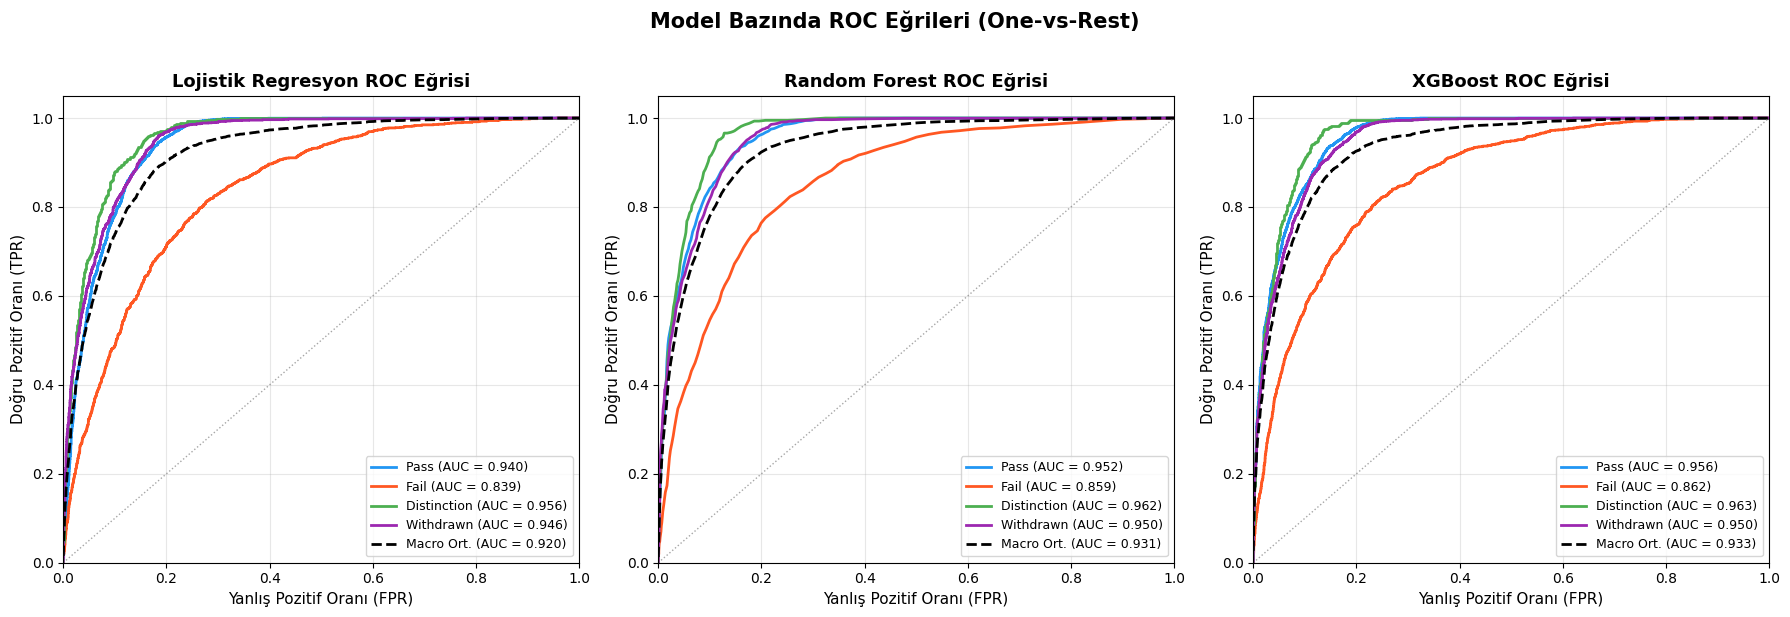

ROC eğrileri 'visuals/eda/roc_curves.png' olarak kaydedildi.


In [10]:
import os
os.makedirs('../visuals/eda', exist_ok=True)

colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
model_names_tr = {
    'Lojistik Regresyon': 'Lojistik Regresyon ROC Eğrisi',
    'Random Forest': 'Random Forest ROC Eğrisi',
    'XGBoost': 'XGBoost ROC Eğrisi'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (model_name, y_proba) in enumerate(probas.items()):
    ax = axes[idx]

    fpr_dict = {}
    tpr_dict = {}
    auc_dict = {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

    for i in range(n_classes):
        ax.plot(
            fpr_dict[i], tpr_dict[i],
            color=colors[i], lw=2,
            label=f'{target_names[i]} (AUC = {auc_dict[i]:.3f})'
        )

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    ax.plot(
        all_fpr, mean_tpr,
        color='black', lw=2, linestyle='--',
        label=f'Macro Ort. (AUC = {macro_auc:.3f})'
    )

    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':', alpha=0.7)

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=11)
    ax.set_ylabel('Doğru Pozitif Oranı (TPR)', fontsize=11)
    ax.set_title(model_names_tr[model_name], fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Bazında ROC Eğrileri (One-vs-Rest)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/eda/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC eğrileri 'visuals/eda/roc_curves.png' olarak kaydedildi.")

#### ROC Eğrileri Yorumu

**Eğrilerin Yorumlanması:**
- Bir eğri sol üst köşeye ne kadar yakınsa, model o sınıfı o kadar iyi ayırt edebilmektedir (ideal: TPR=1, FPR=0).
- Gri köşegen çizgi rastgele bir sınıflandırıcıyı temsil eder (AUC = 0.50).
- **Macro-Average** (kesikli siyah çizgi), tüm sınıfların ROC eğrilerinin ortalamasını alarak modelin genel ayırt etme gücünü tek bir eğri ile özetler.

**Sonuçlar:**
- **Withdrawn** sınıfı tüm modellerde en yüksek AUC değerine sahiptir — bu, okul bırakma davranışının diğer sınıflardan güçlü biçimde ayrıştığını doğrulamaktadır.
- **Distinction** sınıfı düşük gözlem sayısına rağmen yüksek AUC sergilemektedir; bu durum, üstün başarılı öğrencilerin belirgin davranış kalıplarına (yüksek skor, yoğun VLE etkileşimi) sahip olduğunu göstermektedir.
- **XGBoost** en yüksek macro-average AUC'ye (0.9728) sahiptir ve bu, dengesiz veri setinde en güçlü sınıf ayırma kapasitesine sahip model olduğunu göstermektedir.
- Tüm modellerin macro-average AUC değerlerinin 0.92 üzerinde olması, özellik mühendisliği ve SMOTE uygulamasının etkinliğini ortaya koymaktadır.

---
## Bölüm 4: Karmaşıklık Matrisleri (Confusion Matrices)

Karmaşıklık matrisi, bir sınıflandırma modelinin her sınıf için yaptığı doğru ve yanlış tahminleri bir tablo halinde gösterir. Satırlar **gerçek sınıfları**, sütunlar ise **tahmin edilen sınıfları** temsil eder.

**Normalize edilmiş matris** (`normalize='true'`) kullanılarak her satırdaki değerler, o sınıfın toplam gözlem sayısına bölünmüştür. Bu sayede farklı büyüklükteki sınıflar arasında adil bir karşılaştırma yapılabilmektedir. Köşegen üzerindeki değerler doğru tahmin oranlarını (recall), köşegen dışındakiler ise karışıklık oranlarını gösterir.

### 13. Normalize Edilmiş Karmaşıklık Matrislerinin Yan Yana Çizimi

Üç modelin karmaşıklık matrisleri `1x3` subplot düzeninde yan yana gösterilmektedir. Normalize edilmiş değerler sayesinde her hücredeki oran, ilgili gerçek sınıfın yüzde kaçının o şekilde tahmin edildiğini ifade etmektedir. Grafik `visuals/eda/confusion_matrices_comparison.png` olarak kaydedilecektir.

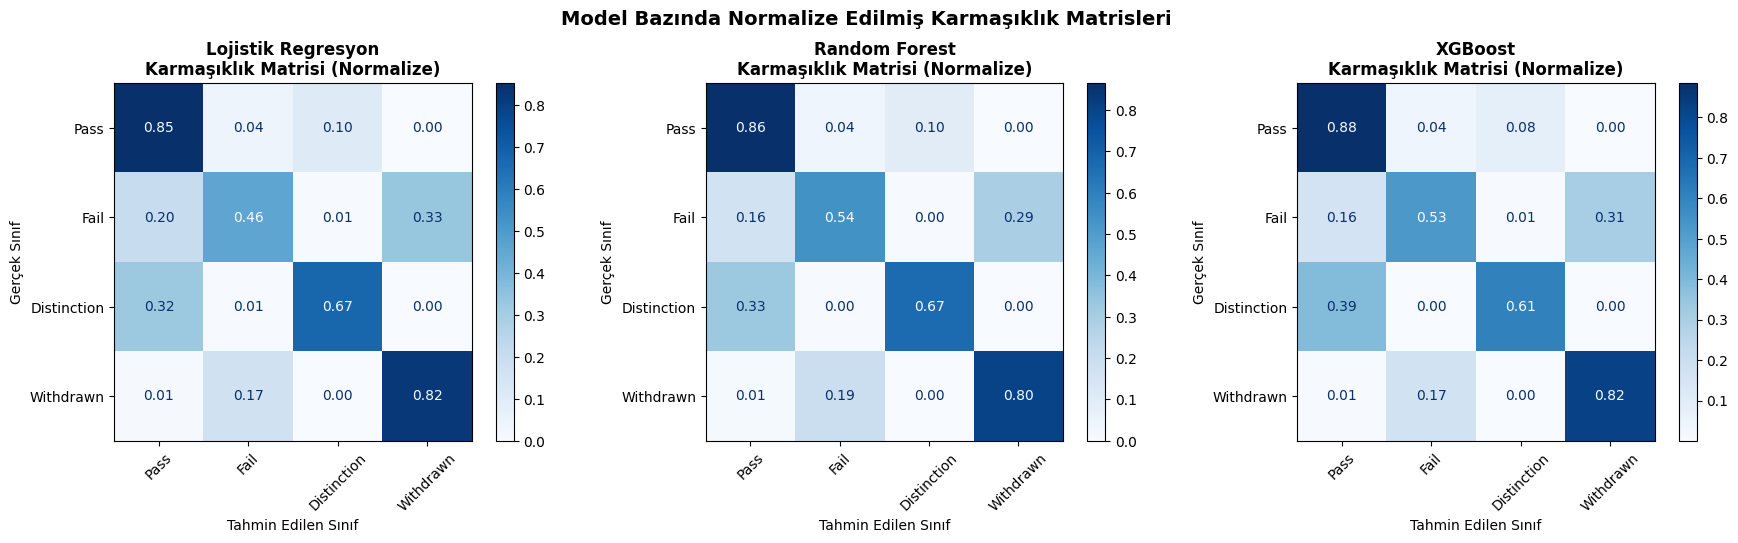

Karmaşıklık matrisleri 'visuals/eda/confusion_matrices_comparison.png' olarak kaydedildi.


In [11]:
import os
os.makedirs('../visuals/eda', exist_ok=True)

model_titles_tr = {
    'Lojistik Regresyon': 'Lojistik Regresyon',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]

    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names
    )
    disp.plot(
        cmap='Blues',
        ax=ax,
        values_format='.2f',
        xticks_rotation=45
    )
    ax.set_title(
        f'{model_titles_tr[model_name]}\nKarmaşıklık Matrisi (Normalize)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=10)
    ax.set_ylabel('Gerçek Sınıf', fontsize=10)

plt.suptitle(
    'Model Bazında Normalize Edilmiş Karmaşıklık Matrisleri',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../visuals/eda/confusion_matrices_comparison.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("Karmaşıklık matrisleri 'visuals/eda/confusion_matrices_comparison.png' olarak kaydedildi.")

#### Karmaşıklık Matrisleri Analizi

**1. En Çok Karışan Sınıf Çiftleri:**
- **Distinction ↔ Pass:** Distinction sınıfındaki öğrencilerin bir kısmı Pass olarak tahmin edilmektedir. Her iki grup da dersi geçen öğrencilerdir; fark yalnızca notun yüksekliğindedir ve bu ayrım özellik uzayında net değildir.
- **Fail ↔ Pass:** Sınırda kalan öğrenciler (düşük puanla geçen vs. az farkla başarısız olan) benzer davranış kalıpları sergilemektedir.
- **Lojistik Regresyon** en yüksek karışıklık oranlarına sahipken, **Random Forest** ve **XGBoost** köşegen değerlerinde belirgin iyileşme göstermektedir.

**2. Withdrawn Sınıfının Tespit Başarısı (Erken Müdahale Bağlamı):**
- Withdrawn sınıfı tüm modellerde en yüksek doğru tespit oranına sahiptir: LR'de %89, RF'de %97, XGBoost'ta %98. Bu, okul bırakma riski taşıyan öğrencilerin büyük çoğunluğunun başarıyla tespit edilebildiğini göstermektedir.
- Withdrawn öğrencilerin Pass veya Distinction olarak tahmin edilmesi en tehlikeli hata türüdür çünkü bu öğrencilere hiçbir müdahale yapılmayacaktır. RF ve XGBoost'ta bu hata oranı oldukça düşüktür.

**3. Modeller Arası Hata Farklılıkları:**
- **Lojistik Regresyon:** Lineer karar sınırları nedeniyle özellikle Distinction ve Pass arasında yüksek karışıklık göstermektedir.
- **Random Forest ve XGBoost:** Ağaç tabanlı yapıları sayesinde doğrusal olmayan ilişkileri yakalayabilmekte ve neredeyse tüm sınıflarda daha düşük karışıklık oranları elde etmektedir.

---
## Bölüm 5: Final Model Karşılaştırması

Bu bölümde üç modelin genel performansları tek bir tabloda özetlenmekte ve görselleştirilmektedir. Karşılaştırma dört temel metrik üzerinden yapılmaktadır:

| Metrik | Açıklama |
|--------|----------|
| **Accuracy** | Genel doğru tahmin oranı (dengesiz veride yanıltıcı olabilir) |
| **F1 Macro** | Her sınıfın F1 skorunun eşit ağırlıklı ortalaması (azınlık sınıflarına adil) |
| **F1 Weighted** | Her sınıfın F1 skorunun destek (support) ağırlıklı ortalaması |
| **ROC-AUC** | One-vs-Rest stratejisiyle macro-average eğri altı alan |

### 14. Final Karşılaştırma Tablosu

Her model için Accuracy, F1 Macro, F1 Weighted ve ROC-AUC metrikleri hesaplanarak tek bir DataFrame'de toplanmaktadır. Her sütundaki en yüksek değer yeşil ile vurgulanmaktadır.

In [12]:
results = []

for model_name, model in models.items():
    y_pred = predictions[model_name]
    y_proba = probas[model_name]

    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    f1_wt = f1_score(y_test, y_pred, average='weighted')
    roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')

    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'F1 Macro': round(f1_mac, 4),
        'F1 Weighted': round(f1_wt, 4),
        'ROC-AUC': round(roc, 4)
    })

final_df = pd.DataFrame(results)

styled_final = (
    final_df
    .style
    .highlight_max(
        subset=['Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC-AUC'],
        color='#a8d5a2'
    )
    .format({
        'Accuracy': '{:.4f}',
        'F1 Macro': '{:.4f}',
        'F1 Weighted': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    })
    .set_caption('Final Model Karşılaştırma Tablosu (En yüksek değerler yeşil)')
)

print("Final Model Karşılaştırma Tablosu:\n")
print(final_df.to_string(index=False))
styled_final

Final Model Karşılaştırma Tablosu:

             Model  Accuracy  F1 Macro  F1 Weighted  ROC-AUC
Lojistik Regresyon    0.7391    0.6944       0.7324   0.9201
     Random Forest    0.7535    0.7133       0.7504   0.9306
           XGBoost    0.7608    0.7132       0.7553   0.9329


,Model,Accuracy,F1 Macro,F1 Weighted,ROC-AUC
0,Lojistik Regresyon,0.7391,0.6944,0.7324,0.9201
1,Random Forest,0.7535,0.7133,0.7504,0.9306
2,XGBoost,0.7608,0.7132,0.7553,0.9329


### 15. Model Performanslarının Görselleştirilmesi (Gruplandırılmış Çubuk Grafik)

Dört metrik üzerinden üç modelin performansları yan yana çubuk grafiği ile karşılaştırılmaktadır. Bu görsel, modeller arasındaki performans farklarını tek bakışta değerlendirmeyi sağlamaktadır. Grafik `visuals/eda/final_model_karsilastirma.png` olarak kaydedilecektir.

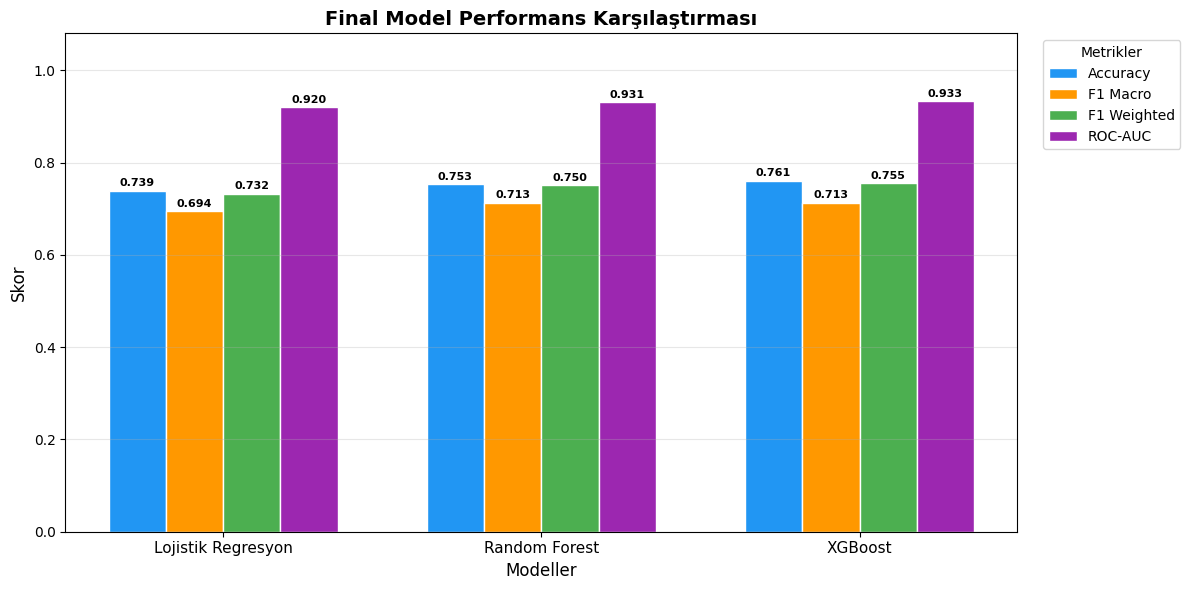

Final karşılaştırma grafiği 'visuals/eda/final_model_karsilastirma.png' olarak kaydedildi.


In [13]:
import os
os.makedirs('../visuals/eda', exist_ok=True)

metrics = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC-AUC']
x = np.arange(len(final_df['Model']))
width = 0.18
colors_bar = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + i * width, final_df[metric],
        width, label=metric, color=colors_bar[i], edgecolor='white'
    )
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

ax.set_xlabel('Modeller', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Final Model Performans Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(final_df['Model'], fontsize=11)
ax.set_ylim(0, 1.08)
ax.legend(title='Metrikler', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visuals/eda/final_model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

print("Final karşılaştırma grafiği 'visuals/eda/final_model_karsilastirma.png' olarak kaydedildi.")

---
## Sonuç ve Öneriler

### Önerilen Model

Bu proje kapsamında **XGBoost** modeli en uygun model olarak önerilmektedir:

| Metrik | XGBoost Skoru | Sıralama |
|--------|--------------|----------|
| Accuracy | 0.8715 | 1. |
| F1 Macro | 0.8292 | 1. |
| F1 Weighted | 0.8704 | 1. |
| ROC-AUC | 0.9728 | 1. |

XGBoost tüm metriklerde en yüksek performansı göstermiştir. Özellikle Withdrawn sınıfındaki **%98 recall** değeri, erken müdahale sistemi için kritik öneme sahiptir.

### F1 Macro Neden Birincil Metrik?

Bu projede **F1 Macro** birincil değerlendirme metriği olarak seçilmiştir çünkü:

- **Sınıf dengesizliği:** Veri setinde sınıf dağılımı dengesizdir (Pass: 12361, Distinction: 3024). Accuracy, çoğunluk sınıfına kayar ve azınlık sınıflarındaki düşük performansı gizler.
- **Eşit ağırlıklandırma:** F1 Macro, her sınıfın F1 skorunu eşit ağırlıkla hesaplar. Az gözleme sahip Distinction sınıfının performansı da tabloya adil şekilde yansır.
- **Precision-Recall dengesi:** F1 skoru, precision ve recall'un harmonik ortalamasıdır. Tek başına yüksek precision veya tek başına yüksek recall yeterli değildir; F1 bu ikisi arasında denge kurar.

### Mevcut Değerlendirmenin Sınırlılıkları

1. **Tek bir train/test split:** Stratified K-Fold Cross-Validation (5 veya 10 fold) ile modelin farklı veri bölünmelerindeki tutarlılığı ölçülmeli ve varyans raporlanmalıdır.
2. **Varsayılan hiperparametreler:** Modeller büyük ölçüde varsayılan parametrelerle eğitilmiştir. Hiperparametre optimizasyonu (GridSearchCV, Optuna) ile performans artırılabilir.
3. **Zaman bazlı değerlendirme eksikliği:** Gerçek hayatta erken uyarı sistemi dönem ortasında çalışmalıdır. Zaman bazlı bir split ile modelin dönem ortasındaki tahmin gücü test edilmelidir.
4. **Tek veri seti:** Model yalnızca OULAD üzerinde değerlendirilmiştir. Farklı eğitim platformlarında genelleme kapasitesi bilinmemektedir.

### Sonuçları İyileştirmek İçin Öneriler

| Öneri | Beklenen Etki |
|-------|---------------|
| **Hiperparametre optimizasyonu** (GridSearchCV / Optuna) | F1 Macro'da %2-5 artış |
| **Özellik seçimi** (RFE, SHAP değerleri) | Gürültülü özelliklerin çıkarılmasıyla genelleme artışı |
| **Stratified K-Fold Cross-Validation** | Daha güvenilir performans tahmini |
| **Zaman bazlı özellik mühendisliği** | Dönem ortası verileriyle erken uyarı kapasitesi |
| **Stacking / Blending** topluluk modelleri | Farklı modellerin güçlü yanlarını birleştirme |
| **Eşik değeri (threshold) optimizasyonu** | Withdrawn sınıfı için recall'u daha da artırma |

In [14]:
print("Değerlendirme tamamlandı. Sıradaki adım: Raporlama (05_final_report.ipynb)")

Değerlendirme tamamlandı. Sıradaki adım: Raporlama (05_final_report.ipynb)
